<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">CNN training</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">אימון CNN על וקטורי EfficientNet-B0</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">כעת נאמן רשת CNN המקבלת וקטור EfficientNet-B0 באורך 1,280 כקלט. המבנה נבחר כרשת קטנה יחסית, כדי לבדוק אם שילובים מקומיים ולא־ליניאריים בין מאפייני הווקטור משפרים את הסיווג בלי ליצור מודל כבד מדי.</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">בהמשך בשלב ניתוח התוצאות נציג למה בחרנו לכלול את                                                 אימון הרשת למרות שהמודל הבסיסי שבו השתמשנו הציג תוצאות                                                                                                   מושלמות על סט הבדיקה.</div>
</div>
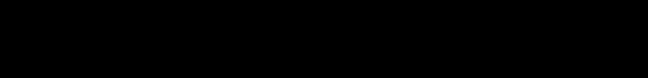
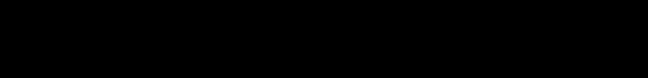

In [1]:
from pathlib import Path
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, Dropout


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path('passport_full_image_output')
EMBEDDINGS_FILE = OUTPUT_DIR / 'full_page_embeddings.npz'
METADATA_FILE = OUTPUT_DIR / 'full_page_embedding_metadata.csv'
LABELS_FILE = Path('passport_page_labels_big_dataset.csv')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
embeddings = np.load(EMBEDDINGS_FILE)
X = embeddings['X'].astype(np.float32)
metadata_df = pd.read_csv(METADATA_FILE, encoding='utf-8-sig')
labels_df = pd.read_csv(LABELS_FILE, encoding='utf-8-sig')

model_df = metadata_df[['image_name', 'image_path', 'vector_row']].merge(
    labels_df,
    on='image_path',
    how='inner',
    validate='one_to_one',
)

vector_rows = model_df['vector_row'].astype(int).to_numpy()
X_model = X[vector_rows]
y = model_df['label'].astype(int).to_numpy()


print('Saved embedding matrix:', X.shape)
print('Labeled vector matrix:', X_model.shape)
print('Labels:', y.shape)
print(pd.Series(y).value_counts().sort_index().rename(index={0: 'No passport', 1: 'Passport'}))

Saved embedding matrix: (839, 1280)
Labeled vector matrix: (839, 1280)
Labels: (839,)
No passport    595
Passport       244
Name: count, dtype: int64


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">חלוקה לסטים של אימון, ולידציה וטסט</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> החלוקה היא 70% לאימון, 15% לולידציה ו־15% לטסט. האינדקסים נשמרים כדי שיהיה אפשר לקשר בהמשך את התחזיות בחזרה לשמות התמונות ולנתיבים המקוריים.</div>
</div>

In [3]:
indices = np.arange(len(y))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=y
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=y[temp_idx]
)

X_train, y_train = X_model[train_idx], y[train_idx]
X_val, y_val = X_model[val_idx], y[val_idx]
X_test, y_test = X_model[test_idx], y[test_idx]

print('Train:', X_train.shape, np.bincount(y_train))
print('Validation:', X_val.shape, np.bincount(y_val))
print('Test:', X_test.shape, np.bincount(y_test))

Train: (587, 1280) [416 171]
Validation: (126, 1280) [89 37]
Test: (126, 1280) [90 36]


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">נרמול הווקטורים והתאמת המבנה ל CNN</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> מאפייני ה Embedding יכולים להיות בטווחים ובהתפלגויות שונים. ללא נרמול, מאפיינים בעלי ערכים גדולים עלולים להשפיע יותר על עדכון המשקלים ולגרום לאימון פחות יציב. בנוסף, שכבת הקונבולוציה החד ממדית מצפה לקלט תלת ממדי ולא למטריצה דו ממדית רגילה.</div>

</div>

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def prepare_for_cnn(vectors):
    # [samples, 1280] -> [samples, 1280, 1]
    return vectors[..., np.newaxis].astype('float32')

X_train_cnn = prepare_for_cnn(X_train)
X_val_cnn = prepare_for_cnn(X_val)
X_test_cnn = prepare_for_cnn(X_test)

print('CNN input shape:', X_train_cnn.shape)

CNN input shape: (587, 1280, 1)


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">בניית רשת CNN </div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> לאחר שהווקטורים הותאמו למבנה תלת־ממדי יש להגדיר מודל שילמד שילובים של מאפיינים המבדילים בין דף עם דרכון לדף ללא דרכון. המודל מחזיר הסתברות אחת לכל דוגמה ולכן מתאים לסיווג בינארי.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"><b>מבנה הרשת:</b> שכבת הקונבולוציה הראשונה מפעילה 64 מסננים שונים, שכל אחד בוחן בכל פעם חמישה מאפיינים סמוכים. מטרתה ללמוד צירופים מקומיים של מאפיינים שעשויים להעיד על הימצאות דרכון. פונקציית ReLU מוסיפה יכולת ללמוד קשרים לא־ליניאריים.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> השכבה הבאה שומרת את הערך החזק ביותר בכל אזור קטן ומקטינה את אורך הייצוג. כך מצמצמים את מספר החישובים ואת הסיכון להתאמת יתר, תוך שמירת התגובות הבולטות של המסננים.</div>

<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;">שכבת הקונבולוציה השניה מקבלת את המאפיינים שכבר זוהו בשכבה הראשונה ולומדת מהם תבניות מורכבות יותר. חלון קטן בגודל 3 מאפשר להתמקד בקשרים מקומיים מדויקים, ו 32 מסננים שומרים על מודל קטן יחסית.</div>

<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;">שכבת האיחוד הגלובלי שומרת את הערך הגבוהה ביותר לכול מאפיין מבין                                                                32 הערכים שהתקבלו לכל מאפיין במסנני                                                                                               השכבה                                                                                                הקודמת.</div>

<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;">שכבת הקונבולוציה השניה מקבלת את המאפיינים שכבר זוהו בשכבה הראשונה ולומדת מהם תבניות מורכבות יותר. חלון קטן בגודל 3 מאפשר להתמקד בקשרים מקומיים מדויקים, ו 32 מסננים שומרים על מודל קטן יחסית.</div>

<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;"> השכבה הבאה מחשבת מהמאפינים שהתקבלי עד כה צירופים חדשים שעוזרים להחליט אם מדובר בדרכון. בעצם מאפשרת למודל ללמוד כיצד הצירופים ביניהם קשורים למחלקה הסופית </div>

<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;">שכבת ה DROPOUT בזמן האימון מכבה באקראי חלק מהנוירונים. כך הרשת אינה נשענת יותר מדי על מאפיינים מסוימים, והסיכון להתאמת יתר לדוגמאות האימון קטן. בזמן חיזוי השכבה אינה מכבה נוירונים.</div>

<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;">לבסוף שכבת הפלט מחזירה ערך בין 0 ל־1, שמתפרש כהסתברות לקיום דרכון.</div>
</div>

In [5]:
model = Sequential([
    Input(shape=(1280, 1)),
    Conv1D(64, kernel_size=5, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, padding='same', activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
    ],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1280, 64)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 640, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 640, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,649 (29.88 KB)

 Trainable params: 7,649 (29.88 KB)

 Non-trainable params: 0 (0.00 B)

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">אימון המודל וטיפול בחוסר איזון</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-bottom: 10px;">  מאחר שבמאגר יכולים להיות יותר דפים ללא דרכון מאשר דפים עם דרכון, מחושב משקל לכל מחלקה כדי שטעות במחלקה הנדירה לא תיבלע בתוך המחלקה הגדולה.</div>
</div>

In [6]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

history = model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
)

model.save(OUTPUT_DIR / 'full_page_cnn.keras')
joblib.dump(scaler, OUTPUT_DIR / 'full_page_cnn_scaler.joblib')

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.4344 - auc: 0.5816 - loss: 0.7170 - precision: 0.3002 - recall: 0.7076 - val_accuracy: 0.6508 - val_auc: 0.6950 - val_loss: 0.7118 - val_precision: 0.4462 - val_recall: 0.7838
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.5247 - auc: 0.6972 - loss: 0.6706 - precision: 0.3594 - recall: 0.8070 - val_accuracy: 0.6905 - val_auc: 0.7475 - val_loss: 0.7340 - val_precision: 0.4848 - val_recall: 0.8649
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5877 - auc: 0.7120 - loss: 0.6557 - precision: 0.3953 - recall: 0.7836 - val_accuracy: 0.6587 - val_auc: 0.7299 - val_loss: 0.6952 - val_precision: 0.4118 - val_recall: 0.3784
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.6712 - auc: 0.7567 - loss: 0.6367 - precision: 0.4610 - recall: 0.7602 - val_accuracy: 0.7063 - val_auc: 0.7653 - val_loss: 0.7020 - val_precision: 0.5000 - val_recall: 0.5946
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━

['passport_full_image_output\\full_page_cnn_scaler.joblib']

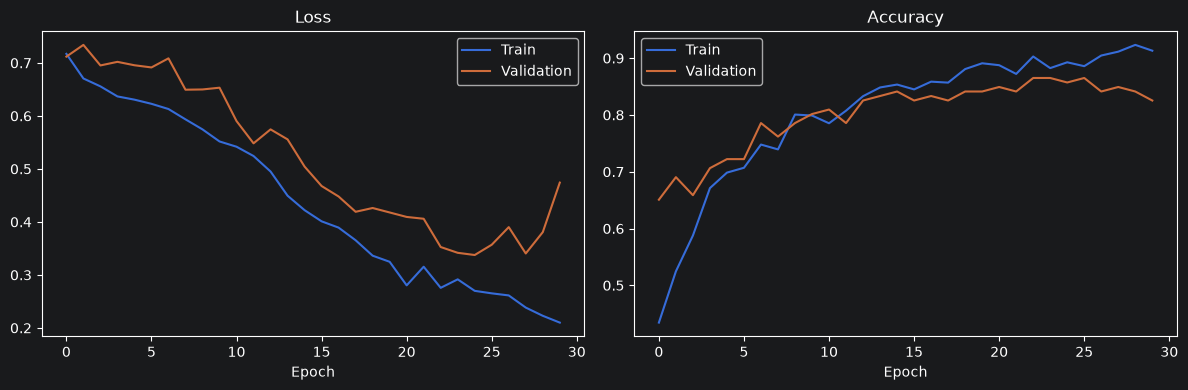

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

 No passport     1.0000    0.9000    0.9474        90
    Passport     0.8000    1.0000    0.8889        36

    accuracy                         0.9286       126
   macro avg     0.9000    0.9500    0.9181       126
weighted avg     0.9429    0.9286    0.9307       126

ROC-AUC: 0.984


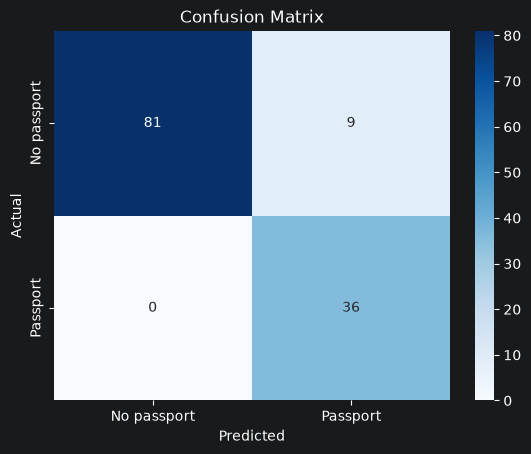

In [8]:
test_probability = model.predict(X_test_cnn, verbose=0).ravel()
test_prediction = (test_probability >= 0.5).astype('int32')

print(classification_report(
    y_test,
    test_prediction,
    target_names=['No passport', 'Passport'],
    digits=4,
    zero_division=0,
))
print('ROC-AUC:', round(roc_auc_score(y_test, test_probability), 4))

cm = confusion_matrix(y_test, test_prediction)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No passport', 'Passport'],
    yticklabels=['No passport', 'Passport'],
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

predictions_df = model_df.iloc[test_idx][
    ['image_name', 'image_path', 'label']
].copy()
predictions_df['prediction'] = test_prediction
predictions_df['passport_probability'] = test_probability
predictions_df.to_csv(
    OUTPUT_DIR / 'full_page_cnn_test_predictions.csv',
    index=False,
    encoding='utf-8-sig',
)